#COMP4211 Project#
---

---
#Data Preparation
---

###Import Packages

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, silhouette_samples, silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

### Dataset Exploration
Dataset(features): https://www.kaggle.com/datasets/vivovinco/20212022-football-player-stats?select=2021-2022+Football+Player+Stats.csv

Dataset(labels): https://www.kaggle.com/datasets/vivovinco/20222023-football-player-stats
Task: perform linear regression to predict "Sales"

In [ ]:
drive.mount('/content/drive')
features_df = pd.read_csv('/content/drive/My Drive/COMP4211/Proposal/2122_data.csv', encoding='latin1', delimiter=';')
labels_df = pd.read_csv('/content/drive/My Drive/COMP4211/Proposal/2223_data.csv', encoding='latin1', delimiter=';')

labels_df['Assists'] = (labels_df['Assists'] * labels_df['MP']).round().astype(int)
data = pd.merge(features_df, labels_df[['Player', 'Goals', 'Assists']], on='Player', how='inner')

data

Mounted at /content/drive


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%,Goals_y,Assists_y
0,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,34.0,1987,34,34,...,1.39,0.00,0.03,0.0,6.77,2.02,1.36,59.8,0,1
1,3,Salis Abdul Samed,GHA,MF,Clermont Foot,Ligue 1,22.0,2000,31,29,...,1.24,0.00,0.00,0.0,8.76,0.88,0.88,50.0,1,0
2,4,Laurent Abergel,FRA,MF,Lorient,Ligue 1,29.0,1993,34,34,...,2.23,0.00,0.00,0.0,8.87,0.43,0.43,50.0,0,1
3,7,Matthis Abline,FRA,FW,Rennes,Ligue 1,19.0,2003,7,1,...,0.00,0.00,0.00,0.0,6.36,0.00,1.82,0.0,1,0
4,7,Matthis Abline,FRA,FW,Rennes,Ligue 1,19.0,2003,7,1,...,0.00,0.00,0.00,0.0,6.36,0.00,1.82,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,2918,Szymon ?urkowski,POL,MF,Empoli,Serie A,24.0,1997,35,29,...,1.91,0.00,0.04,0.0,8.05,1.02,1.56,39.4,0,5
2066,2918,Szymon ?urkowski,POL,MF,Empoli,Serie A,24.0,1997,35,29,...,1.91,0.00,0.04,0.0,8.05,1.02,1.56,39.4,0,0
2067,2919,Martin Ødegaard,NOR,MF,Arsenal,Premier League,23.0,1998,36,32,...,0.81,0.00,0.06,0.0,7.44,0.55,0.81,40.5,8,5
2068,2920,Milan ?uri?,BIH,FW,Salernitana,Serie A,32.0,1990,33,23,...,0.17,0.04,0.00,0.0,3.24,12.40,4.81,72.0,1,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2070 entries, 0 to 2069
Columns: 145 entries, Rk to Assists_y
dtypes: float64(133), int64(7), object(5)
memory usage: 2.3+ MB


In [ ]:
data.describe()

,Rk,Age,Born,MP,Starts,Min,90s,Goals_x,Shots,SoT,...,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%,Goals_y,Assists_y
count,2070.000000,2069.000000,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000,...,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000,2070.000000
mean,1458.844444,26.124698,1994.413043,22.584541,17.176812,1532.495652,17.026812,0.142348,1.299599,0.422063,...,1.032483,0.011517,0.011043,0.003300,7.560169,1.625923,1.810300,42.637488,1.182126,1.187440
std,847.989347,4.218169,44.059682,10.589185,11.058946,942.337672,10.469079,0.266968,1.374184,0.547805,...,0.781742,0.040733,0.030742,0.017593,3.148994,1.517327,1.882001,21.152787,2.179071,1.992164
min,2.000000,16.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,727.250000,23.000000,1992.000000,15.000000,7.000000,759.500000,8.425000,0.000000,0.432500,0.070000,...,0.560000,0.000000,0.000000,0.000000,5.392500,0.610000,0.940000,31.725000,0.000000,0.000000
50%,1454.000000,26.000000,1996.000000,25.000000,17.000000,1540.000000,17.100000,0.060000,0.990000,0.250000,...,0.970000,0.000000,0.000000,0.000000,7.500000,1.290000,1.410000,44.750000,0.000000,0.000000
75%,2199.000000,29.000000,1998.750000,31.000000,26.000000,2298.750000,25.500000,0.200000,1.940000,0.650000,...,1.420000,0.000000,0.000000,0.000000,9.357500,2.267500,2.100000,57.675000,1.000000,2.000000
max,2921.000000,41.000000,2006.000000,38.000000,38.000000,3420.000000,38.000000,5.000000,20.000000,10.000000,...,10.000000,0.710000,0.500000,0.420000,40.000000,20.000000,30.000000,100.000000,25.000000,20.000000


In [ ]:
numerical_data = data.select_dtypes(include=['int64', 'float64'])


plt.figure(figsize=(100, 60))
sns.heatmap(numerical_data.corr(), annot=True, cmap='YlGnBu', linecolor='r', linewidths=0.5)
plt.title('Heat Map')
plt.show()


"\nplt.figure(figsize=(100, 60))\nsns.heatmap(numerical_data.corr(), annot=True, cmap='YlGnBu', linecolor='r', linewidths=0.5)\nplt.title('Heat Map')\nplt.show()\n"

## Preprocessing

###Identifying types of features

In [ ]:
categorical_data = data.select_dtypes(include=["object"])
print(f"Categorical features are: {categorical_data.columns.tolist()}")
print(f"\n{len(categorical_data.columns)} categorical features in total.")

continuous_numerical_data = data.select_dtypes(include=["float64"])
print(f"\n\nContinuous numerical features are: {continuous_numerical_data.columns.tolist()}")
print(f"\n{len(continuous_numerical_data.columns)} continuous numerical features in total.")

discrete_numerical_data = data.select_dtypes(include=["int64"])
print(f"\n\nDiscrete numerical features are: {discrete_numerical_data.columns.tolist()}")
print(f"\n{len(discrete_numerical_data.columns)} discrete numerical features in total.")


Categorical features are: ['Player', 'Nation', 'Pos', 'Squad', 'Comp']

5 categorical features in total.


Continuous numerical features are: ['Age', '90s', 'Goals_x', 'Shots', 'SoT', 'SoT%', 'G/Sh', 'G/SoT', 'ShoDist', 'ShoFK', 'ShoPK', 'PKatt', 'PasTotCmp', 'PasTotAtt', 'PasTotCmp%', 'PasTotDist', 'PasTotPrgDist', 'PasShoCmp', 'PasShoAtt', 'PasShoCmp%', 'PasMedCmp', 'PasMedAtt', 'PasMedCmp%', 'PasLonCmp', 'PasLonAtt', 'PasLonCmp%', 'Assists_x', 'PasAss', 'Pas3rd', 'PPA', 'CrsPA', 'PasProg', 'PasAtt', 'PasLive', 'PasDead', 'PasFK', 'TB', 'PasPress', 'Sw', 'PasCrs', 'CK', 'CkIn', 'CkOut', 'CkStr', 'PasGround', 'PasLow', 'PasHigh', 'PaswLeft', 'PaswRight', 'PaswHead', 'TI', 'PaswOther', 'PasCmp', 'PasOff', 'PasOut', 'PasInt', 'PasBlocks', 'SCA', 'ScaPassLive', 'ScaPassDead', 'ScaDrib', 'ScaSh', 'ScaFld', 'ScaDef', 'GCA', 'GcaPassLive', 'GcaPassDead', 'GcaDrib', 'GcaSh', 'GcaFld', 'GcaDef', 'Tkl', 'TklWon', 'TklDef3rd', 'TklMid3rd', 'TklAtt3rd', 'TklDri', 'TklDriAtt', 'TklDri%', 'TklDriP

### Handling Missing Value

In [ ]:
def check_missing_values(df):
    missing_values = df.isnull().sum()
    missing_features = missing_values[missing_values > 0]
    print("Features with missing values:\n" , missing_features)
    print("Proportion of missing values:\n", missing_features / len(df))

check_missing_values(data)

Features with missing values:
 Nation    1
Age       1
dtype: int64
Proportion of missing values:
 Nation    0.000483
Age       0.000483
dtype: float64


In [ ]:
def impute_missing_values(df, strategy='median'):
    imputer = SimpleImputer(strategy=strategy)
    imputed_data = imputer.fit_transform(df)
    imputed_df = pd.DataFrame(imputed_data, columns=df.columns)
    return imputed_df

numerical_data_imputed = impute_missing_values(numerical_data, strategy='median')
numerical_data_imputed

,Rk,Age,Born,MP,Starts,Min,90s,Goals_x,Shots,SoT,...,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%,Goals_y,Assists_y
0,2.0,34.0,1987.0,34.0,34.0,2983.0,33.1,0.06,0.54,0.18,...,1.39,0.00,0.03,0.0,6.77,2.02,1.36,59.8,0.0,1.0
1,3.0,22.0,2000.0,31.0,29.0,2462.0,27.4,0.04,0.66,0.18,...,1.24,0.00,0.00,0.0,8.76,0.88,0.88,50.0,1.0,0.0
2,4.0,29.0,1993.0,34.0,34.0,2956.0,32.8,0.00,0.91,0.21,...,2.23,0.00,0.00,0.0,8.87,0.43,0.43,50.0,0.0,1.0
3,7.0,19.0,2003.0,7.0,1.0,103.0,1.1,0.00,1.82,0.00,...,0.00,0.00,0.00,0.0,6.36,0.00,1.82,0.0,1.0,0.0
4,7.0,19.0,2003.0,7.0,1.0,103.0,1.1,0.00,1.82,0.00,...,0.00,0.00,0.00,0.0,6.36,0.00,1.82,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,2918.0,24.0,1997.0,35.0,29.0,2307.0,25.6,0.23,1.84,0.66,...,1.91,0.00,0.04,0.0,8.05,1.02,1.56,39.4,0.0,5.0
2066,2918.0,24.0,1997.0,35.0,29.0,2307.0,25.6,0.23,1.84,0.66,...,1.91,0.00,0.04,0.0,8.05,1.02,1.56,39.4,0.0,0.0
2067,2919.0,23.0,1998.0,36.0,32.0,2785.0,30.9,0.23,1.72,0.68,...,0.81,0.00,0.06,0.0,7.44,0.55,0.81,40.5,8.0,5.0
2068,2920.0,32.0,1990.0,33.0,23.0,2165.0,24.1,0.21,2.07,0.79,...,0.17,0.04,0.00,0.0,3.24,12.40,4.81,72.0,1.0,0.0


### Standardization

In [ ]:
def scale_numerical_data(df, method='standard'):
    if method == 'minmax':
        scaler = MinMaxScaler()
    elif method == 'robust':
        scaler = RobustScaler()
    else:
        scaler = StandardScaler()

    scaled_data = scaler.fit_transform(df)
    scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
    return scaled_df


numerical_training_data_standard = scale_numerical_data(numerical_data_imputed, method='standard')
numerical_training_data_minmax = scale_numerical_data(numerical_data_imputed, method='minmax')
numerical_training_data_robust = scale_numerical_data(numerical_data_imputed, method='robust')

print(numerical_data_imputed.head())

print("Standard Scaled Data:")
print(numerical_training_data_standard.head())

print("\nMin-Max Scaled Data:")
print(numerical_training_data_minmax.head())

print("\nRobust Scaled Data:")
print(numerical_training_data_robust.head())

    Rk   Age    Born    MP  Starts     Min   90s  Goals_x  Shots   SoT  ...  \
0  2.0  34.0  1987.0  34.0    34.0  2983.0  33.1     0.06   0.54  0.18  ...   
1  3.0  22.0  2000.0  31.0    29.0  2462.0  27.4     0.04   0.66  0.18  ...   
2  4.0  29.0  1993.0  34.0    34.0  2956.0  32.8     0.00   0.91  0.21  ...   
3  7.0  19.0  2003.0   7.0     1.0   103.0   1.1     0.00   1.82  0.00  ...   
4  7.0  19.0  2003.0   7.0     1.0   103.0   1.1     0.00   1.82  0.00  ...   

   TklW  PKwon  PKcon   OG  Recov  AerWon  AerLost  AerWon%  Goals_y  \
0  1.39    0.0   0.03  0.0   6.77    2.02     1.36     59.8      0.0   
1  1.24    0.0   0.00  0.0   8.76    0.88     0.88     50.0      1.0   
2  2.23    0.0   0.00  0.0   8.87    0.43     0.43     50.0      0.0   
3  0.00    0.0   0.00  0.0   6.36    0.00     1.82      0.0      1.0   
4  0.00    0.0   0.00  0.0   6.36    0.00     1.82      0.0      1.0   

   Assists_y  
0        1.0  
1        0.0  
2        1.0  
3        0.0  
4        0.0  

[

###Encoding
---

Consider "player" as key. There is no need to do one hot encoding for "player".

In [ ]:
def preprocess_categorical_data(data):

    categorical_columns = data.select_dtypes(exclude=['number']).columns.tolist()

    encoder = OrdinalEncoder()
    encoded_data = encoder.fit_transform(data[categorical_columns])

    encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_columns))

    return encoded_df

encoded_df = preprocess_categorical_data(categorical_data)
encoded_df

,Player,Nation,Pos,Squad,Comp
0,1766.0,56.0,0.0,74.0,2.0
1,1514.0,39.0,7.0,22.0,2.0
2,955.0,34.0,7.0,51.0,2.0
3,1153.0,34.0,3.0,75.0,2.0
4,1153.0,34.0,3.0,75.0,2.0
...,...,...,...,...,...
2065,1610.0,71.0,7.0,28.0,4.0
2066,1610.0,71.0,7.0,28.0,4.0
2067,1118.0,66.0,7.0,3.0,3.0
2068,1207.0,10.0,3.0,78.0,4.0


## Feature Selection

In [ ]:
def select_best_features(X, y, k=23):

    selector_goal = SelectKBest(score_func=f_classif, k=k)
    selector_goal.fit(X, y.iloc[:, -2])
    scores_goal = selector_goal.scores_

    selector_assist = SelectKBest(score_func=f_classif, k=k)
    selector_assist.fit(X, y.iloc[:, -1])
    scores_assist = selector_assist.scores_

    combined_scores = scores_goal + scores_assist
    selected_indices = combined_scores.argsort()[-k:][::-1]

    score_df = pd.DataFrame({
        'Feature': X.columns,
        'Goal Score': scores_goal,
        'Assist Score': scores_assist,
        'Combined Score': combined_scores
    }).sort_values(by='Combined Score', ascending=False)

    X_selected = X.iloc[:, selected_indices]

    return score_df, X_selected, selected_indices

score_df, X_selected, selected_indices = select_best_features(
    X=numerical_training_data_robust.iloc[:, :-2],
    y=data.iloc[:, -2:],
    k=28
)

score_df[:28]

,Feature,Goal Score,Assist Score,Combined Score
122,RecProg,24.532519,14.686128,39.218647
101,TouDef3rd,20.714620,16.464059,37.178679
103,TouAtt3rd,11.937735,22.857471,34.795206
104,TouAttPen,19.251901,11.239552,30.491453
90,PresAtt3rd,16.189650,11.453844,27.643494
116,CPA,11.957914,15.524261,27.482175
32,PasAss,9.122241,17.721387,26.843627
121,Rec%,18.982348,6.795325,25.777673
117,CarMis,15.333321,10.162500,25.495821
16,PKatt,19.236060,4.775120,24.011180


---
# Regression
---

##Preprocess data

In [ ]:
def preprocess(data):
    data_without_player = data.drop(columns=['Player'], errors='ignore')
    numerical_data = data_without_player.select_dtypes(include=['number'])
    categorical_data_encoded = preprocess_categorical_data(data_without_player)
    combined_data = pd.concat([categorical_data_encoded, numerical_data], axis=1)
    data_imputed = impute_missing_values(combined_data)
    scaled_data = scale_numerical_data(data_imputed, "robust")
    score_df, X_selected, selected_indices = select_best_features(
    X=scaled_data.iloc[:, :-2],
    y=data,
    k=23
    )
    selected_columns = scaled_data.columns[:-2][selected_indices]
    final_data = pd.DataFrame(X_selected, columns=selected_columns)
    final_data = pd.concat([data['Player'], final_data], axis=1)
    final_data = pd.concat([final_data, data.iloc[:, -2:]], axis=1)

    return final_data

preprocessed_data = preprocess(data)
preprocessed_data

,Player,RecProg,TouDef3rd,TouAtt3rd,TouAttPen,PresAtt3rd,CPA,PasAss,Rec%,CarMis,...,SCA,PasTotPrgDist,Goals_x,CK,DriAtt,CarProg,ScaPassDead,ScaFld,Goals_y,Assists_y
0,Yunis Abdelhamid,-0.398696,1.028299,-0.918476,-0.276083,-0.478798,-0.338983,-0.519802,0.394737,-0.335704,...,-0.621984,0.481113,0.00,0.000000,-0.326316,-0.301215,0.0,-0.266667,0,1
1,Salis Abdul Samed,-0.145319,0.462314,-0.348879,-0.349920,0.178207,-0.084746,-0.212871,0.163158,-0.113798,...,-0.176944,-0.083458,-0.10,0.000000,0.131579,-0.268826,0.0,0.733333,1,0
2,Laurent Abergel,-0.119236,-0.042029,-0.299039,-0.401284,0.064412,-0.186441,0.143564,0.189474,-0.108108,...,0.117962,0.034365,-0.30,0.142857,0.368421,-0.262348,0.5,1.133333,0,1
3,Matthis Abline,0.888682,-0.707761,-0.348879,0.327448,0.893183,-0.338983,0.143564,-2.952632,0.443812,...,-0.471850,-0.980226,-0.30,0.000000,0.284211,-0.307692,0.0,-0.266667,1,0
4,Matthis Abline,0.888682,-0.707761,-0.348879,0.327448,0.893183,-0.338983,0.143564,-2.952632,0.443812,...,-0.471850,-0.980226,-0.30,0.000000,0.284211,-0.307692,0.0,-0.266667,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,Szymon ?urkowski,0.160224,-0.109274,0.249199,0.215088,0.304885,0.050847,-0.024752,-0.152632,0.563300,...,0.294906,-0.463112,0.85,0.000000,0.147368,0.906883,0.0,1.266667,0,5
2066,Szymon ?urkowski,0.160224,-0.109274,0.249199,0.215088,0.304885,0.050847,-0.024752,-0.152632,0.563300,...,0.294906,-0.463112,0.85,0.000000,0.147368,0.906883,0.0,1.266667,0,0
2067,Martin Ødegaard,0.240335,-0.407397,0.790317,0.199037,0.755770,0.372881,1.678218,-0.100000,0.199147,...,1.367292,-0.124915,0.85,4.761905,0.042105,0.913360,3.5,0.133333,8,5
2068,Milan ?uri?,0.516069,-0.633231,0.071200,1.528090,0.588298,-0.050847,0.559406,-1.284211,0.517781,...,0.284182,-0.868403,0.75,0.000000,-0.300000,-1.017004,0.0,1.133333,1,0


### Data Split

Spliting data into x and y. Further split the data into train and test with the training-to-validation ratio 80:20. Random_state is set to 4211.

In [ ]:
x = preprocessed_data.iloc[:, 1:-2]
y = data[['Goals_y', 'Assists_y']]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4211)

## Building the regression model

###Linear Regression

In [ ]:
model = MultiOutputRegressor(LinearRegression())
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse_goals = mean_squared_error(y_test['Goals_y'], y_pred[:, 0])
mse_assists = mean_squared_error(y_test['Assists_y'], y_pred[:, 1])
r2_goals = r2_score(y_test['Goals_y'], y_pred[:, 0])
r2_assists = r2_score(y_test['Assists_y'], y_pred[:, 1])

print(f'Goals - MSE: {mse_goals}, R^2: {r2_goals}')
print(f'Assists - MSE: {mse_assists}, R^2: {r2_assists}')

Goals - MSE: 3.000327639568913, R^2: 0.12901975523940012
Assists - MSE: 2.995993436937643, R^2: 0.17079846801185217


###Random Forest

In [ ]:
model = RandomForestRegressor(n_estimators=100)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse_goals = mean_squared_error(y_test['Goals_y'], y_pred[:, 0])
mse_assists = mean_squared_error(y_test['Assists_y'], y_pred[:, 1])
r2_goals = r2_score(y_test['Goals_y'], y_pred[:, 0])
r2_assists = r2_score(y_test['Assists_y'], y_pred[:, 1])

print(f'Goals - MSE: {mse_goals}, R^2: {r2_goals}')
print(f'Assists - MSE: {mse_assists}, R^2: {r2_assists}')

Goals - MSE: 3.3365563337819344, R^2: 0.03141423158956613
Assists - MSE: 3.214434796391387, R^2: 0.11034042171727743


###Deceision Tree

In [ ]:
model = DecisionTreeRegressor()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse_goals = mean_squared_error(y_test['Goals_y'], y_pred[:, 0])
r2_goals = r2_score(y_test['Goals_y'], y_pred[:, 0])
mse_assists = mean_squared_error(y_test['Assists_y'], y_pred[:, 1])
r2_assists = r2_score(y_test['Assists_y'], y_pred[:, 1])

print(f'Goals - MSE: {mse_goals}, R^2: {r2_goals}')
print(f'Assists - MSE: {mse_assists}, R^2: {r2_assists}')

Goals - MSE: 8.670893719806763, R^2: -1.5171174756952674
Assists - MSE: 5.46256038647343, R^2: -0.5118736193465878


###Gradient Boosting

In [ ]:
model = MultiOutputRegressor(GradientBoostingRegressor())
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse_goals = mean_squared_error(y_test['Goals_y'], y_pred[:, 0])
r2_goals = r2_score(y_test['Goals_y'], y_pred[:, 0])
mse_assists = mean_squared_error(y_test['Assists_y'], y_pred[:, 1])
r2_assists = r2_score(y_test['Assists_y'], y_pred[:, 1])

print(f'Goals - MSE: {mse_goals}, R^2: {r2_goals}')
print(f'Assists - MSE: {mse_assists}, R^2: {r2_assists}')

Goals - MSE: 3.1889842336184446, R^2: 0.07425368093007201
Assists - MSE: 3.3367547961985564, R^2: 0.07648589787807647


###SVR

In [ ]:
model = MultiOutputRegressor(SVR(kernel='rbf'))
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse_goals = mean_squared_error(y_test['Goals_y'], y_pred[:, 0])
r2_goals = r2_score(y_test['Goals_y'], y_pred[:, 0])
mse_assists = mean_squared_error(y_test['Assists_y'], y_pred[:, 1])
r2_assists = r2_score(y_test['Assists_y'], y_pred[:, 1])

print(f'Goals - MSE: {mse_goals}, R^2: {r2_goals}')
print(f'Assists - MSE: {mse_assists}, R^2: {r2_assists}')

Goals - MSE: 2.749753779355474, R^2: 0.20176010506688313
Assists - MSE: 3.580675701802309, R^2: 0.008975873951819757


###Ridge

In [ ]:
model = Ridge(alpha=2.0)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse_goals = mean_squared_error(y_test['Goals_y'], y_pred[:, 0])
r2_goals = r2_score(y_test['Goals_y'], y_pred[:, 0])
mse_assists = mean_squared_error(y_test['Assists_y'], y_pred[:, 1])
r2_assists = r2_score(y_test['Assists_y'], y_pred[:, 1])

print(f'Goals - MSE: {mse_goals}, R^2: {r2_goals}')
print(f'Assists - MSE: {mse_assists}, R^2: {r2_assists}')

Goals - MSE: 2.995687280157962, R^2: 0.13036682857973303
Assists - MSE: 2.984839308108409, R^2: 0.17388559784303348


In [ ]:
def select_and_sort_features(X, y, k=23):
    from sklearn.feature_selection import SelectKBest, f_classif
    import pandas as pd

    selector_goal = SelectKBest(score_func=f_classif, k=k)
    selector_goal.fit(X, y.iloc[:, -2])
    scores_goal = selector_goal.scores_

    selector_assist = SelectKBest(score_func=f_classif, k=k)
    selector_assist.fit(X, y.iloc[:, -1])
    scores_assist = selector_assist.scores_

    score_df = pd.DataFrame({
        'Feature': X.columns,
        'Goal Score': scores_goal,
        'Assist Score': scores_assist
    })

    sorted_goal_indices = selector_goal.get_support(indices=True)
    sorted_assist_indices = selector_assist.get_support(indices=True)

    X_selected_goals = X.iloc[:, sorted_goal_indices]
    X_selected_assists = X.iloc[:, sorted_assist_indices]

    return score_df, X_selected_goals, X_selected_assists

In [ ]:
for k in range(13,31):
    print(f"\nNow k = {k}")

    score_df, X_selected_goals, X_selected_assists = select_and_sort_features(
        X=numerical_training_data_robust.iloc[:, :-2],
        y=data.iloc[:, -2:],
        k=k
    )

    X_train_goals, X_test_goals, y_train_goals, y_test_goals = train_test_split(
        X_selected_goals, data['Goals_y'], test_size=0.2, random_state=42
    )

    X_train_assists, X_test_assists, y_train_assists, y_test_assists = train_test_split(
        X_selected_assists, data['Assists_y'], test_size=0.2, random_state=42
    )

    model_goals = Ridge(alpha=2.0)
    model_goals.fit(X_train_goals, y_train_goals)
    y_pred_goals = model_goals.predict(X_test_goals)

    model_assists = Ridge(alpha=2.0)
    model_assists.fit(X_train_assists, y_train_assists)
    y_pred_assists = model_assists.predict(X_test_assists)


    mse_goals = mean_squared_error(y_test_goals, y_pred_goals)
    r2_goals = r2_score(y_test_goals, y_pred_goals)

    mse_assists = mean_squared_error(y_test_assists, y_pred_assists)
    r2_assists = r2_score(y_test_assists, y_pred_assists)


    print(f'Goals - MSE: {mse_goals}, R^2: {r2_goals}')
    print(f'Assists - MSE: {mse_assists}, R^2: {r2_assists}')


Now k = 13
Goals - MSE: 3.8359504909611983, R^2: 0.2096779164382303
Assists - MSE: 4.058167449291786, R^2: 0.1552304650564269

Now k = 14
Goals - MSE: 3.800209656872535, R^2: 0.21704161170274083
Assists - MSE: 4.0667543678581115, R^2: 0.15344296680887726

Now k = 15
Goals - MSE: 3.7964876396508123, R^2: 0.2178084600790836
Assists - MSE: 4.0647835978764935, R^2: 0.1538532126801122

Now k = 16
Goals - MSE: 3.7995399196290482, R^2: 0.21717959787721275
Assists - MSE: 4.066449023989102, R^2: 0.15350652879872717

Now k = 17
Goals - MSE: 3.799908260530144, R^2: 0.21710370848575666
Assists - MSE: 4.069371715938425, R^2: 0.1528981258312142

Now k = 18
Goals - MSE: 3.8045094243460795, R^2: 0.21615572926068893
Assists - MSE: 4.0732010005595125, R^2: 0.15210100175268781

Now k = 19
Goals - MSE: 3.8127301661559097, R^2: 0.21446200724553843
Assists - MSE: 4.079722596228091, R^2: 0.1507434320099713

Now k = 20
Goals - MSE: 3.8065074227840587, R^2: 0.2157440810154424
Assists - MSE: 4.084502815280587,

##Data Visualisation

###Scatter Plot of Actual v.s. Predicted Values

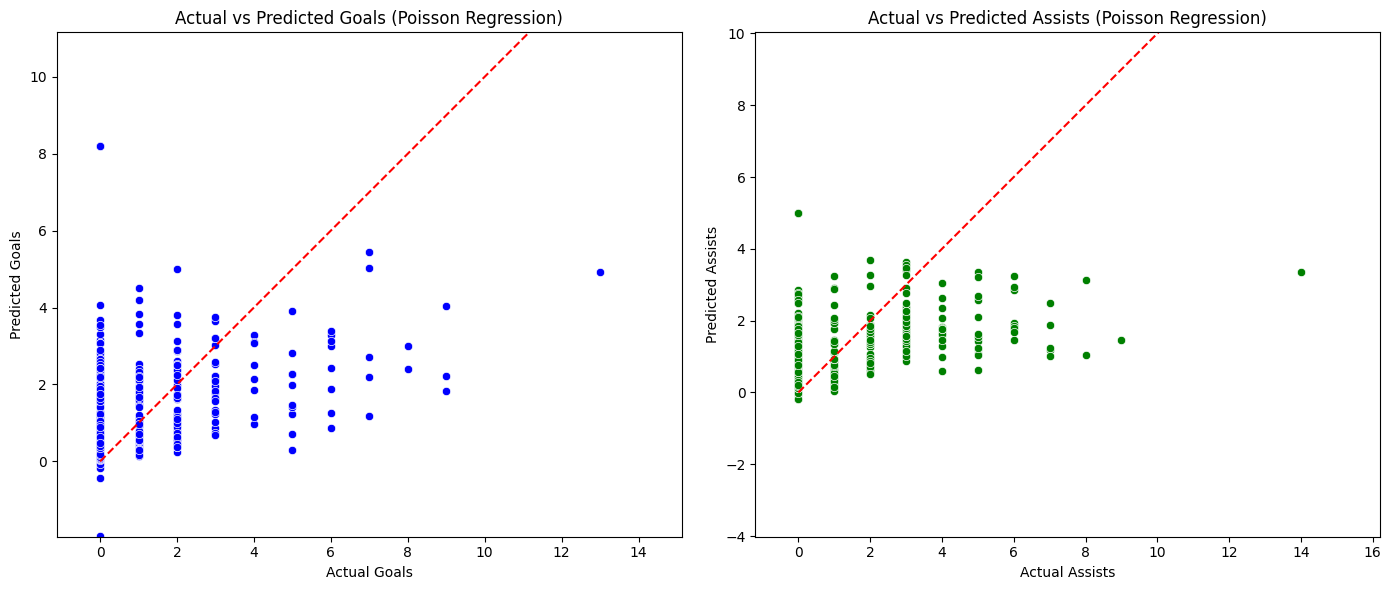

In [ ]:
results = pd.DataFrame({
    'Actual Goals': y_test['Goals_y'],
    'Predicted Goals': y_pred[:, 0],
    'Actual Assists': y_test['Assists_y'],
    'Predicted Assists': y_pred[:, 1]
})

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=results, x='Actual Goals', y='Predicted Goals', color='blue')
plt.plot([0, results['Actual Goals'].max()],
         [0, results['Actual Goals'].max()], 'r--')
plt.title('Actual vs Predicted Goals (Poisson Regression)')
plt.xlabel('Actual Goals')
plt.ylabel('Predicted Goals')
plt.axis('equal')
plt.xlim(0, results['Actual Goals'].max() + 1)
plt.ylim(0, results['Predicted Goals'].max() + 1)


plt.subplot(1, 2, 2)
sns.scatterplot(data=results, x='Actual Assists', y='Predicted Assists', color='green')
plt.plot([0, results['Actual Assists'].max()],
         [0, results['Actual Assists'].max()], 'r--')
plt.title('Actual vs Predicted Assists (Poisson Regression)')
plt.xlabel('Actual Assists')
plt.ylabel('Predicted Assists')
plt.axis('equal')
plt.xlim(0, results['Actual Assists'].max() + 1)
plt.ylim(0, results['Predicted Assists'].max() + 1)

plt.tight_layout()
plt.show()

###Residual Plots

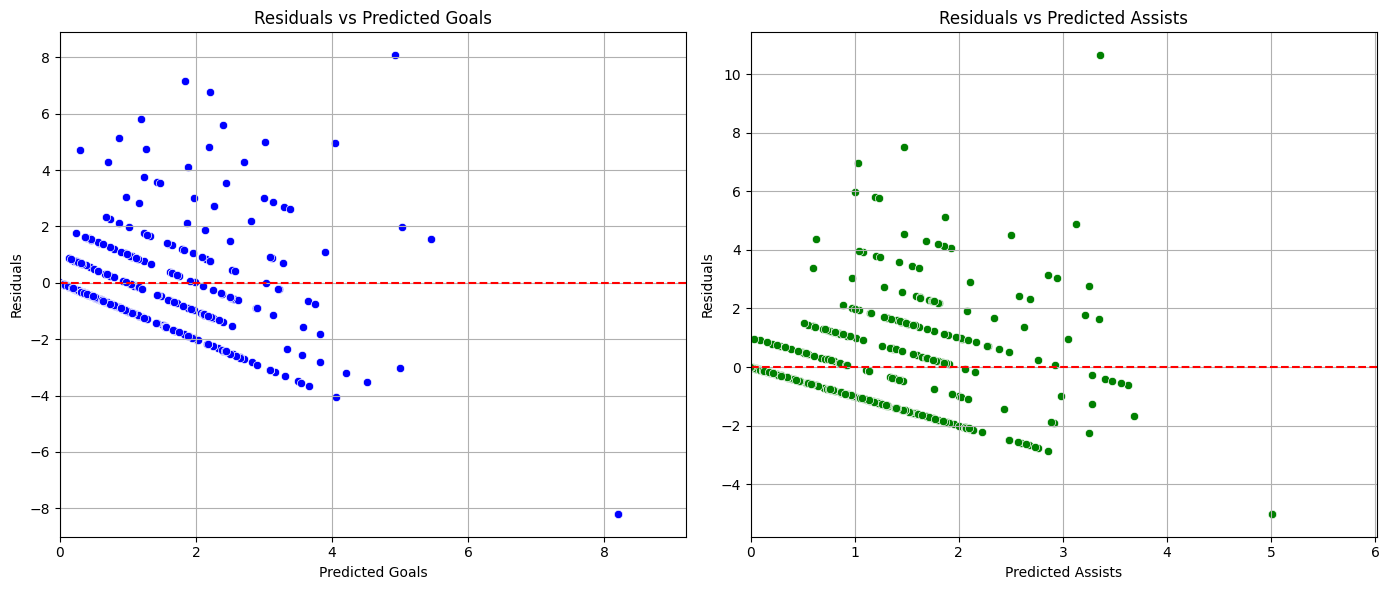

In [ ]:
results['Residual Goals'] = results['Actual Goals'] - results['Predicted Goals']
results['Residual Assists'] = results['Actual Assists'] - results['Predicted Assists']

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=results, x='Predicted Goals', y='Residual Goals', color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Goals')
plt.xlabel('Predicted Goals')
plt.ylabel('Residuals')
plt.xlim(0, results['Predicted Goals'].max() + 1)
plt.grid()

plt.subplot(1, 2, 2)
sns.scatterplot(data=results, x='Predicted Assists', y='Residual Assists', color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Assists')
plt.xlabel('Predicted Assists')
plt.ylabel('Residuals')
plt.xlim(0, results['Predicted Assists'].max() + 1)
plt.grid()

plt.tight_layout()
plt.show()

###Histogram of Residuals

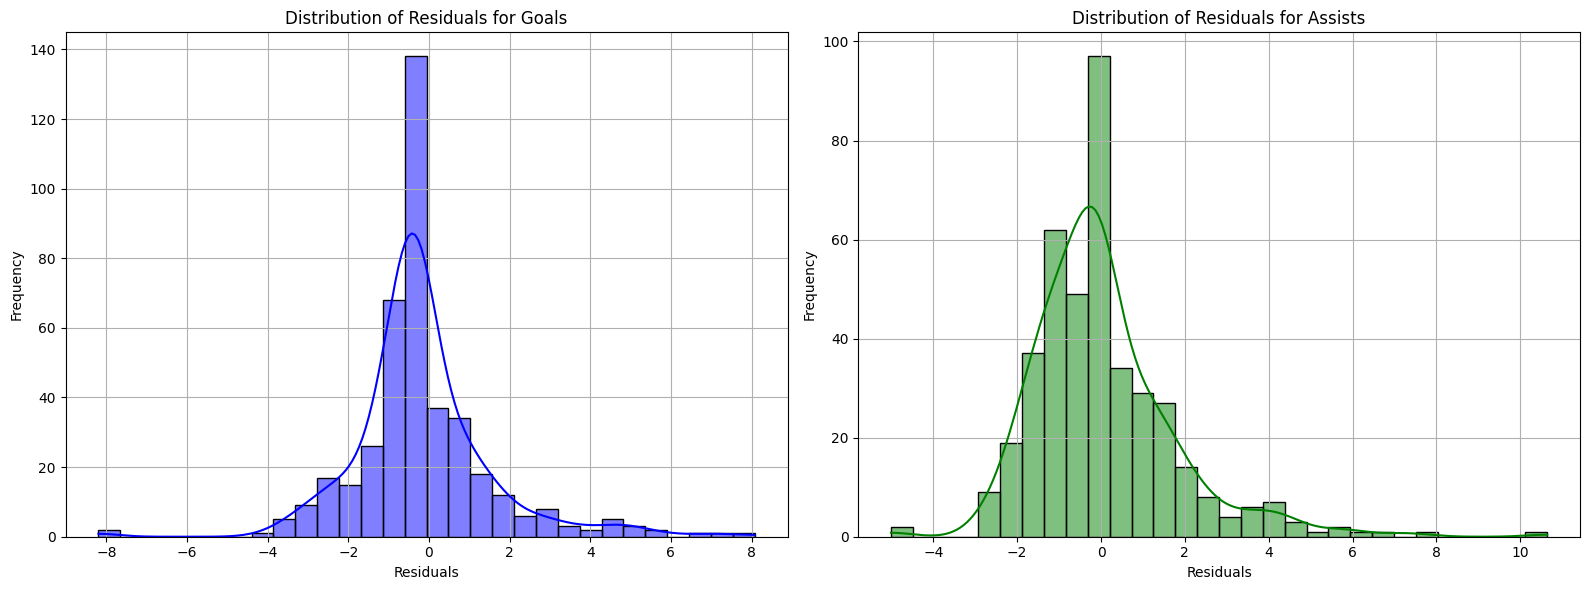

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(results['Residual Goals'], bins=30, kde=True, color='blue')
plt.title('Distribution of Residuals for Goals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid()

plt.subplot(1, 2, 2)
sns.histplot(results['Residual Assists'], bins=30, kde=True, color='green')
plt.title('Distribution of Residuals for Assists')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid()

plt.tight_layout()
plt.show()

###Regression Line Plots

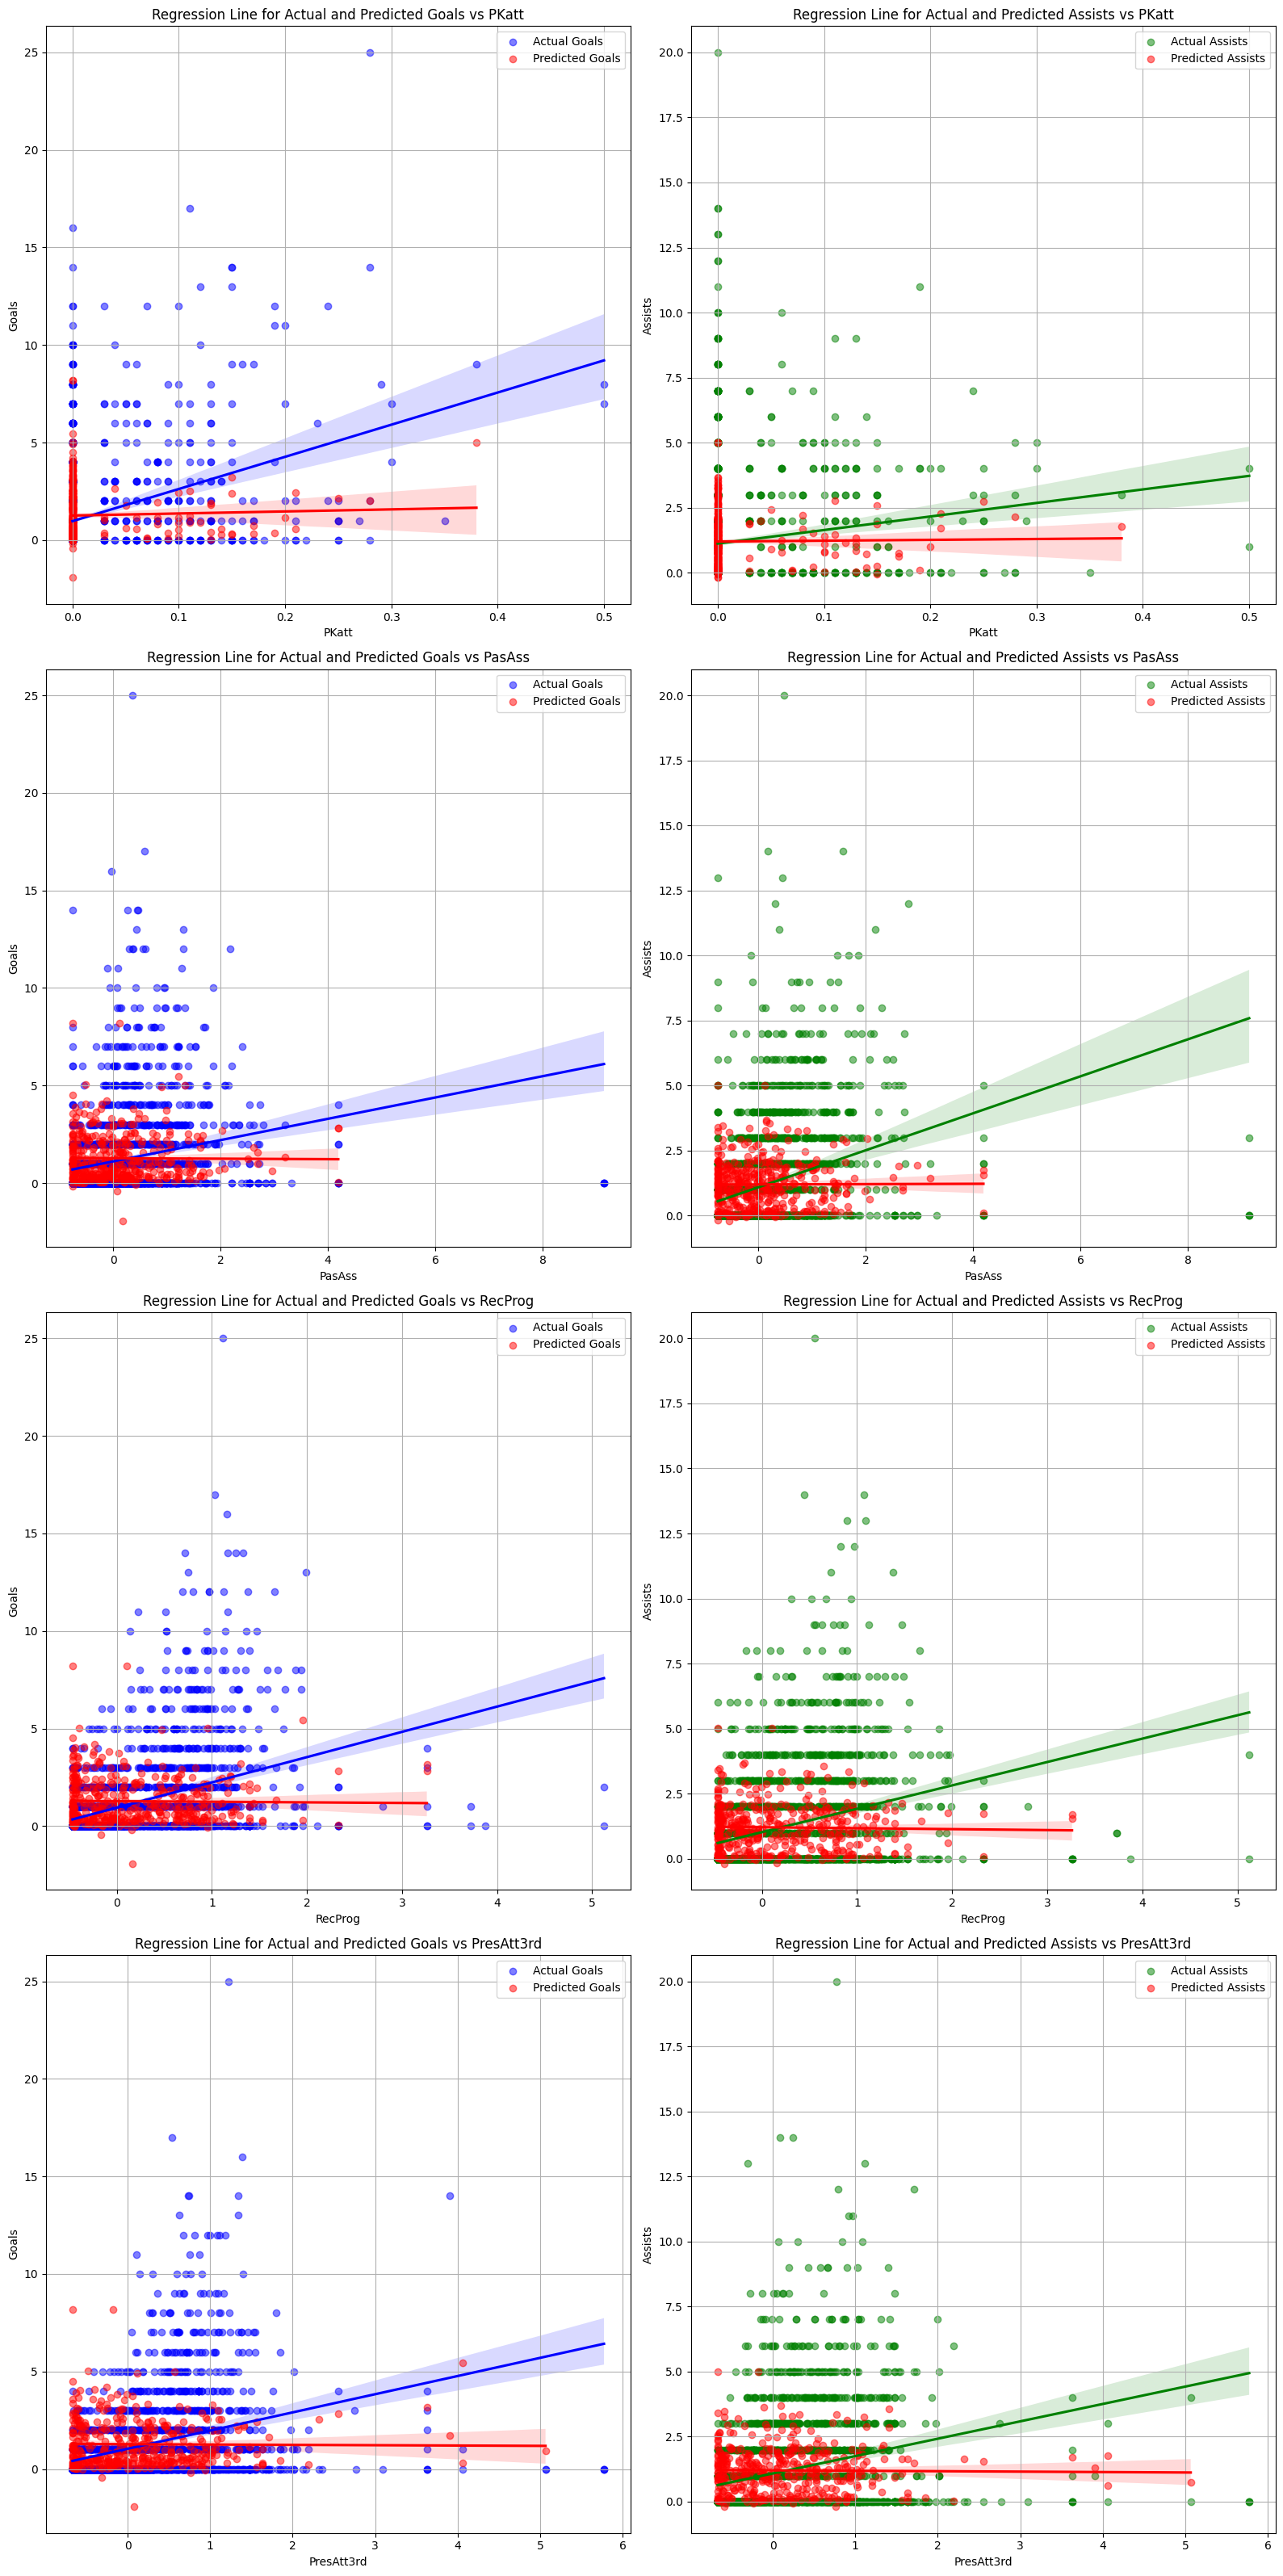

In [ ]:
plt.figure(figsize=(16, 32))

y_pred_df = pd.DataFrame(y_pred, columns=['Predicted Goals', 'Predicted Assists'])
results = pd.concat([preprocessed_data.reset_index(drop=True), y_pred_df.reset_index(drop=True)], axis=1)

selected_features = np.random.choice(preprocessed_data.columns[1:-2], size=4, replace=False)

for i, feature in enumerate(selected_features):
    plt.subplot(4, 2, i * 2 + 1)
    sns.regplot(data=results, x=feature, y='Goals_y', color='blue', label='Actual Goals', scatter_kws={'alpha':0.5})
    sns.regplot(data=results, x=feature, y='Predicted Goals', color='red', label='Predicted Goals', scatter_kws={'alpha':0.5})
    plt.title(f'Regression Line for Actual and Predicted Goals vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Goals')
    plt.legend()
    plt.grid()


    plt.subplot(4, 2, i * 2 + 2)
    sns.regplot(data=results, x=feature, y='Assists_y', color='green', label='Actual Assists', scatter_kws={'alpha':0.5})
    sns.regplot(data=results, x=feature, y='Predicted Assists', color='red', label='Predicted Assists', scatter_kws={'alpha':0.5})
    plt.title(f'Regression Line for Actual and Predicted Assists vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Assists')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

##Application

In [ ]:
def predict_player_performance(player_name):
    matching_players = preprocessed_data[preprocessed_data['Player'].str.contains(player_name, case=False, na=False)]
    if matching_players.empty:
        return []

    performance_list = []

    for _, row in matching_players.iterrows():
        index_to_drop = preprocessed_data[(preprocessed_data['Player'] == row['Player'])].index
        X = preprocessed_data.drop(index=index_to_drop).iloc[:, 1:-2]
        y = preprocessed_data.drop(index=index_to_drop).iloc[:, -2:]
        model = MultiOutputRegressor(LinearRegression())
        model.fit(X, y)
        predicted = model.predict(matching_players.iloc[:, 1:-2])

        performance_list.append({
            'Player': row['Player'],
            'Actual Goals': row['Goals_y'],
            'Predicted Goals': predicted[0][0],
            'Actual Assists': row['Assists_y'],
            'Predicted Assists': predicted[0][1]
        })
    return performance_list

player_names = ["Bruno Fernandes"]
results = []
for name in player_names:
    performance = predict_player_performance(name)
    if not performance:
        results.append({'Player': name, 'Actual Goals': 'N/A', 'Predicted Goals': 'N/A',   'Actual Assists': 'N/A','Predicted Assists': 'N/A'})
    else:
        results.extend(performance)

performance_df = pd.DataFrame(results)
performance_df

,Player,Actual Goals,Predicted Goals,Actual Assists,Predicted Assists
0,Bruno Fernandes,5,2.213227,4,2.706476


#Classification

##Position Selection

In [ ]:
def filter_by_position(data, position_substring):
    if 'Pos' not in data.columns:
        return pd.Dataframe([])
    filtered_data = data[data['Pos'].str.contains(position_substring, case=False, na=False)]
    return filtered_data

data_pos = filter_by_position(data, 'FW')
data_pos

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%,Goals_y,Assists_y
3,7,Matthis Abline,FRA,FW,Rennes,Ligue 1,19.0,2003,7,1,...,0.00,0.00,0.00,0.0,6.36,0.00,1.82,0.0,1,0
4,7,Matthis Abline,FRA,FW,Rennes,Ligue 1,19.0,2003,7,1,...,0.00,0.00,0.00,0.0,6.36,0.00,1.82,0.0,1,0
5,8,Tammy Abraham,ENG,FW,Roma,Serie A,24.0,1997,37,36,...,0.64,0.03,0.03,0.0,3.67,2.39,2.89,45.3,6,4
9,14,Che Adams,SCO,FW,Southampton,Premier League,25.0,1996,30,23,...,0.40,0.00,0.00,0.0,5.29,2.47,4.89,33.5,4,2
11,16,Sargis Adamyan,ARM,FWMF,Hoffenheim,Bundesliga,29.0,1993,13,2,...,2.16,0.00,0.00,0.0,7.03,1.35,3.51,27.8,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2052,2903,Edon Zhegrova,KVX,MFFW,Lille,Ligue 1,23.0,1999,13,5,...,2.08,0.00,0.00,0.0,7.17,0.19,0.94,16.7,1,4
2056,2909,Hakim Ziyech,MAR,FWMF,Chelsea,Premier League,29.0,1993,23,14,...,0.75,0.00,0.00,0.0,8.91,0.75,1.22,37.9,0,2
2058,2911,Simon Zoller,GER,FW,Bochum,Bundesliga,30.0,1991,10,6,...,0.30,0.00,0.00,0.0,6.21,1.21,1.52,44.4,3,1
2068,2920,Milan ?uri?,BIH,FW,Salernitana,Serie A,32.0,1990,33,23,...,0.17,0.04,0.00,0.0,3.24,12.40,4.81,72.0,1,0


##Preprocessing

In [ ]:
def preprocess_classification(data):
    data_without_player = data.drop(columns=['Player'], errors='ignore')
    numerical_data = data_without_player.select_dtypes(include=['number'])
    categorical_data_encoded = preprocess_categorical_data(data_without_player)
    categorical_data_encoded.reset_index(drop=True, inplace=True)
    numerical_data.reset_index(drop=True, inplace=True)
    combined_data = pd.concat([categorical_data_encoded, numerical_data], axis=1)
    data_imputed = impute_missing_values(combined_data)
    scaled_data = scale_numerical_data(data_imputed, "minmax")
    scaled_data.reset_index(drop=True, inplace=True)
    data.reset_index(drop=True, inplace=True)
    final_data = pd.concat([data['Player'], scaled_data.iloc[:, :-2]], axis=1)
    return final_data

preprocessed_data_classification = preprocess_classification(data_pos)
preprocessed_data_classification

,Player,Nation,Pos,Squad,Comp,Rk,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,Matthis Abline,0.365854,0.25,0.770833,0.50,0.000000,0.125000,0.998504,0.162162,0.026316,...,0.000,0.091,0.000,0.000000,0.000000,0.0,0.212000,0.0000,0.060667,0.000
1,Matthis Abline,0.365854,0.25,0.770833,0.50,0.000000,0.125000,0.998504,0.162162,0.026316,...,0.000,0.091,0.000,0.000000,0.000000,0.0,0.212000,0.0000,0.060667,0.000
2,Tammy Abraham,0.329268,0.25,0.781250,1.00,0.000343,0.333333,0.995513,0.972973,0.947368,...,0.050,0.070,0.128,0.042254,0.272727,0.0,0.122333,0.1195,0.096333,0.453
3,Che Adams,0.780488,0.25,0.843750,0.75,0.002402,0.375000,0.995015,0.783784,0.605263,...,0.031,0.048,0.080,0.000000,0.000000,0.0,0.176333,0.1235,0.163000,0.335
4,Sargis Adamyan,0.048780,0.75,0.406250,0.00,0.003089,0.541667,0.993519,0.324324,0.052632,...,0.108,0.162,0.432,0.000000,0.000000,0.0,0.234333,0.0675,0.117000,0.278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736,Edon Zhegrova,0.560976,1.00,0.510417,0.50,0.993823,0.291667,0.996510,0.324324,0.131579,...,0.000,0.283,0.416,0.000000,0.000000,0.0,0.239000,0.0095,0.031333,0.167
737,Hakim Ziyech,0.573171,0.75,0.218750,0.75,0.995882,0.541667,0.993519,0.594595,0.368421,...,0.034,0.442,0.150,0.000000,0.000000,0.0,0.297000,0.0375,0.040667,0.379
738,Simon Zoller,0.402439,0.25,0.125000,0.00,0.996568,0.583333,0.992522,0.243243,0.157895,...,0.045,0.167,0.060,0.000000,0.000000,0.0,0.207000,0.0605,0.050667,0.444
739,Milan ?uri?,0.121951,0.25,0.802083,1.00,0.999657,0.666667,0.992024,0.864865,0.605263,...,0.025,0.029,0.034,0.056338,0.000000,0.0,0.108000,0.6200,0.160333,0.720


##Classification Model

###K means

In [ ]:
kmeans_data = preprocessed_data_classification.iloc[:, 1:]
reference_players = []

feature_columns = kmeans_data.columns
for feature in feature_columns:
    low = kmeans_data[feature].quantile(0.1)
    lq = kmeans_data[feature].quantile(0.25)
    median = kmeans_data[feature].median()
    uq = kmeans_data[feature].quantile(0.75)
    top = kmeans_data[feature].quantile(0.9)

    reference_players.append([low, lq, median, uq, top])
reference_df = pd.DataFrame(reference_players, index=feature_columns)

kmeans = KMeans(n_clusters=5, init=reference_df.T.values, n_init=1, random_state=4211)
kmeans_data['Cluster'] = kmeans.fit_predict(kmeans_data)
cluster_means = kmeans_data.groupby('Cluster').mean()

from sklearn.metrics import silhouette_score
silhouette = silhouette_score(kmeans_data, kmeans_data['Cluster'])
print(f"Kmeans: {silhouette}")

performance_levels = ['Poor', 'Below Average', 'Average', 'Above Average', 'Elite']
cluster_ranking = cluster_means.mean(axis=1).sort_values().index
performance_mapping = {cluster: performance_levels[i] for i, cluster in enumerate(cluster_ranking)}
kmeans_data['Performance Level'] = kmeans_data['Cluster'].map(performance_mapping)

Kmeans: 0.21484411535676973


###Hierarchical Clustering

In [ ]:
kmeans_data = preprocessed_data_classification.iloc[:, 1:]

hierarchical_model = AgglomerativeClustering(n_clusters=5)
kmeans_data['Cluster'] = hierarchical_model.fit_predict(kmeans_data)
hierarchical_means = kmeans_data.groupby('Cluster').mean()

silhouette = silhouette_score(kmeans_data, kmeans_data['Cluster'])
print(f"Hierarchical: {silhouette}")

performance_levels = ['Poor', 'Below Average', 'Average', 'Above Average', 'Elite']
cluster_ranking = cluster_means.mean(axis=1).sort_values().index
performance_mapping = {cluster: performance_levels[i] for i, cluster in enumerate(cluster_ranking)}
kmeans_data['Performance Level'] = kmeans_data['Cluster'].map(performance_mapping)

Hierarchical: 0.2652404271472739


###Gaussian Mixture Model

In [ ]:
kmeans_data = preprocessed_data_classification.iloc[:, 1:]

gmm_model = GaussianMixture(n_components=5)
kmeans_data['Cluster'] = gmm_model.fit_predict(kmeans_data)
gmm_means = kmeans_data.groupby('Cluster').mean()

silhouette_gmm = silhouette_score(kmeans_data, kmeans_data['Cluster'])
print(f"GMM: {silhouette_gmm}")

performance_levels = ['Poor', 'Below Average', 'Average', 'Above Average', 'Elite']
cluster_ranking = cluster_means.mean(axis=1).sort_values().index
performance_mapping = {cluster: performance_levels[i] for i, cluster in enumerate(cluster_ranking)}
kmeans_data['Performance Level'] = kmeans_data['Cluster'].map(performance_mapping)

GMM: 0.2169388062895953


##Data Visualisation

###Distribution of performances

<ipython-input-38-cd7d87b309f5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=kmeans_data, x='Performance Level', palette='viridis')


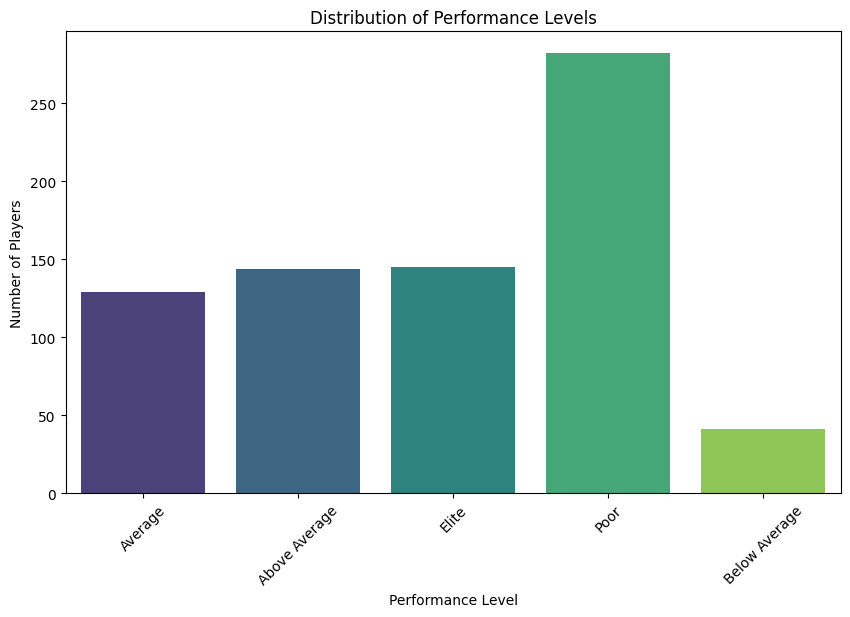

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=kmeans_data, x='Performance Level', palette='viridis')
plt.title('Distribution of Performance Levels')
plt.xlabel('Performance Level')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.show()

###Features Plot

<ipython-input-39-109284f94314>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  goals_assists['Goals_mp'] = goals_assists['Goals_x'] * goals_assists['MP']
<ipython-input-39-109284f94314>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  goals_assists['Assists_mp'] = goals_assists['Assists_x'] * goals_assists['MP']


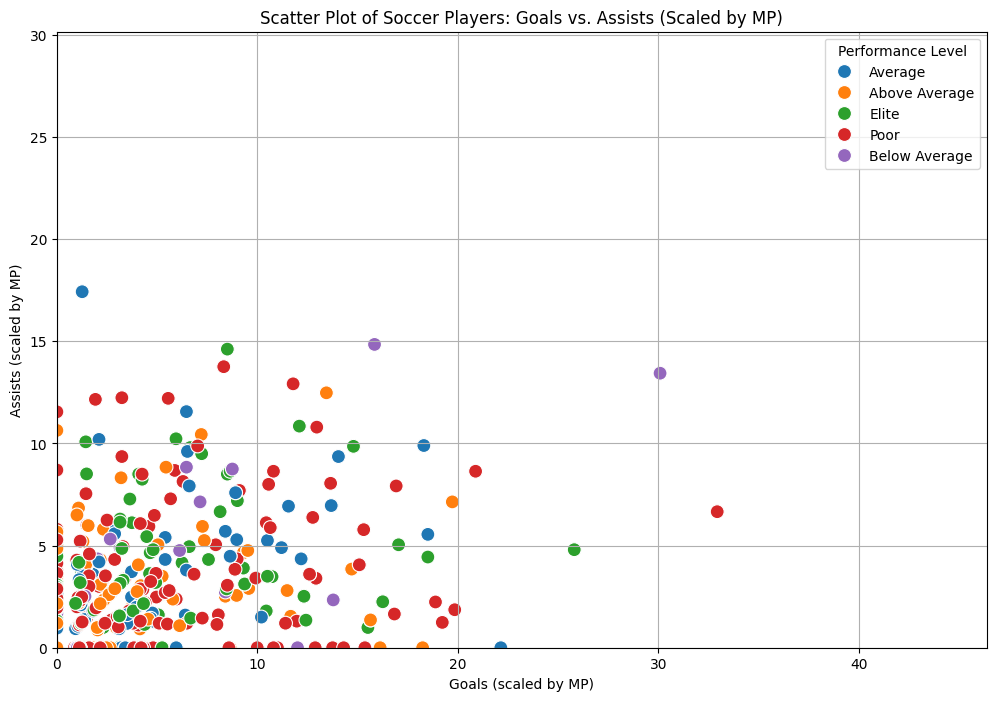

In [ ]:
goals_assists = data[['Goals_x', 'Assists_x', 'MP']]

#print(goals_assists)
goals_assists['Goals_mp'] = goals_assists['Goals_x'] * goals_assists['MP']
goals_assists['Assists_mp'] = goals_assists['Assists_x'] * goals_assists['MP']

kmeans_data.reset_index(drop=True, inplace=True)
combined_data = pd.concat([kmeans_data, goals_assists[['Goals_mp', 'Assists_mp']].reset_index(drop=True)], axis=1)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=combined_data, x='Goals_mp', y='Assists_mp', hue='Performance Level', s=100)
plt.xlim(0, combined_data['Goals_mp'].max() + 10)
plt.ylim(0, combined_data['Assists_mp'].max() + 10)
plt.title('Scatter Plot of Soccer Players: Goals vs. Assists (Scaled by MP)')
plt.xlabel('Goals (scaled by MP)')
plt.ylabel('Assists (scaled by MP)')
plt.legend(title='Performance Level')
plt.grid(True)

plt.show()

###PCA

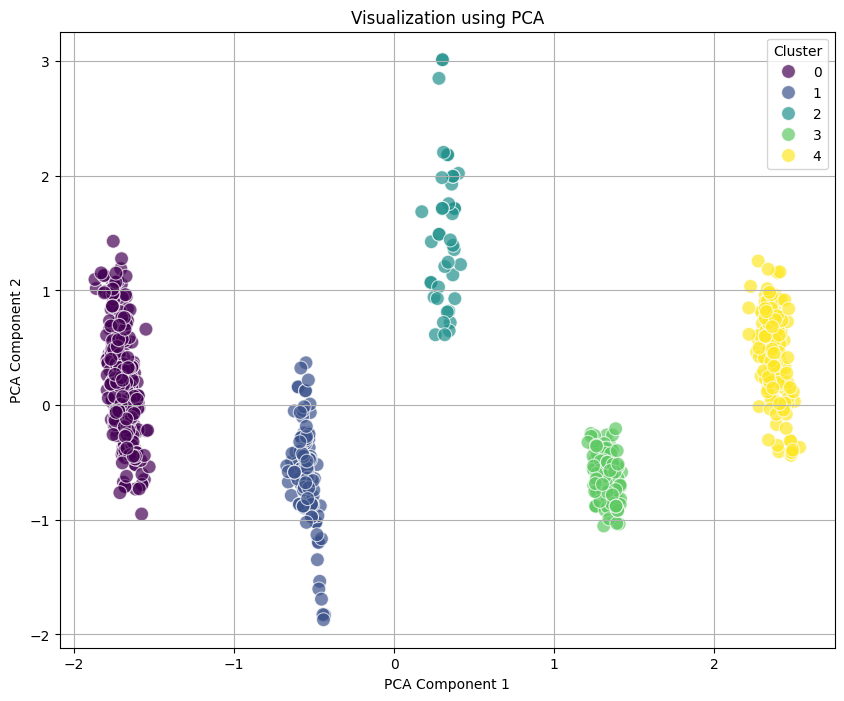

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(kmeans_data.iloc[:, :-1])

pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = kmeans_data['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Visualization using PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

###Silhouette Scores

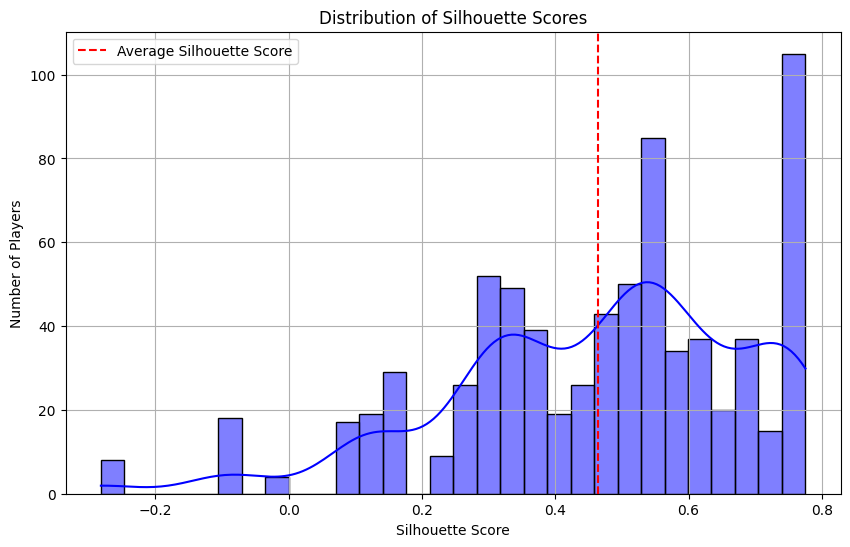

In [ ]:

#print(preprocessed_data_classification.columns)
kmeans_data = preprocessed_data_classification.iloc[:, 1:-2]

X_numeric = kmeans_data[['Squad', 'Comp']]

hierarchical_model = AgglomerativeClustering(n_clusters=5)
kmeans_data['Cluster'] = hierarchical_model.fit_predict(X_numeric)

silhouette_vals = silhouette_samples(X_numeric, kmeans_data['Cluster'])
kmeans_data['Silhouette Score'] = silhouette_vals


plt.figure(figsize=(10, 6))
sns.histplot(kmeans_data['Silhouette Score'], bins=30, kde=True, color='blue')
plt.title('Distribution of Silhouette Scores')
plt.xlabel('Silhouette Score')
plt.ylabel('Number of Players')
plt.axvline(silhouette_score(X_numeric, kmeans_data['Cluster']), color='red', linestyle='--', label='Average Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

##Application

In [ ]:
def get_player_performance(player_name):

    matching_players = data[data['Player'].str.contains(player_name, case=False, na=False)]
    if matching_players.empty:
        return []

    performance_list = []

    for _, row in matching_players.iterrows():

        pos = data.loc[data['Player'] == row['Player'], 'Pos'].str[:2].values[0]
        data_pos = filter_by_position(data, pos)

        preprocessed_data_classification = preprocess_classification(data_pos)

        kmeans_data = preprocessed_data_classification.iloc[:, 1:]


        reference_players = []

        feature_columns = kmeans_data.columns

        for feature in feature_columns:
            low = kmeans_data[feature].quantile(0.1)
            lq = kmeans_data[feature].quantile(0.25)
            median = kmeans_data[feature].median()
            uq = kmeans_data[feature].quantile(0.75)
            top = kmeans_data[feature].quantile(0.9)

            reference_players.append([low, lq, median, uq, top])

        reference_df = pd.DataFrame(reference_players, index=feature_columns)

        n_clusters = 5
        kmeans = KMeans(n_clusters=n_clusters, init=reference_df.T.values, n_init=1, random_state=4211)
        kmeans_data['Cluster'] = kmeans.fit_predict(kmeans_data)
        cluster_means = kmeans_data.groupby('Cluster').mean()
        performance_levels = ['Poor', 'Below Average', 'Average', 'Above Average', 'Elite']

        cluster_ranking = cluster_means.mean(axis=1).sort_values().index
        performance_mapping = {cluster: performance_levels[i] for i, cluster in enumerate(cluster_ranking)}

        kmeans_data['Performance Level'] = kmeans_data['Cluster'].map(performance_mapping)

        performance_means = kmeans_data.groupby('Performance Level').mean()

        final_data = pd.concat([preprocessed_data_classification.iloc[:,0], kmeans_data], axis=1)

        performance_list.append({
            'Player': row['Player'],
            'Position': pos,
            'Performance Level': final_data.loc[final_data['Player'] == row['Player'], 'Performance Level'].values[0]
        })

    return performance_list


#player_names = ["kepa", "diger", "alonso", "jorginho", "Thiago Silva", "N'Golo", "Mateo Kova", "Pulisic", "Werner", "Ruben Loftus-Cheek", "Edouard Mendy","Mason Mount" , "Callum Hudson-Odoi", "Ben Chilwell", "Hakim Ziyech", "Reece James", "Azpilicueta"]
player_names = ["gallagher"]
results = []

for name in player_names:
    performance = get_player_performance(name)
    if not performance:
        results.append({'Player': name, 'Position': 'N/A', 'Performance Level': 'No performance data found'})
    else:
        results.extend(performance)

performance_df = pd.DataFrame(results)
performance_df

,Player,Position,Performance Level
0,Conor Gallagher,MF,Below Average
